# Understanding SVM Kernels and Their Effect on Decision Boundaries

**Objective:**  
Explore Support Vector Machines (SVMs) and how different kernels (linear, polynomial, RBF) affect decision boundaries.  
Dataset: Iris (petal length and width, two classes: Setosa and Versicolor)

In [19]:
import numpy
import matplotlib
import sklearn

print("All libraries imported successfully!")

All libraries imported successfully!


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Set plots to be PDF-friendly
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["figure.dpi"] = 120

In [21]:
# Load Iris dataset
iris = datasets.load_iris()
X = iris.data[:, 2:4]  # petal length & width
y = iris.target

# Only use two classes (Setosa and Versicolor)
X = X[y != 2]
y = y[y != 2]

print("Dataset shape:", X.shape)
print("Classes:", np.unique(y))

Dataset shape: (100, 2)
Classes: [0 1]


## Dataset

We are using the Iris dataset with 150 samples.  
For visualization, we focus on **petal length** and **petal width**, and only **2 classes** (Setosa and Versicolor) for simplicity.  
This allows us to plot decision boundaries in 2D.

## Support Vector Machines (SVM) and Kernels

### Linear Kernel
- Separates classes using a straight line (hyperplane)
- Works well if data is linearly separable

### Polynomial Kernel
- Creates curved decision boundaries
- Formula: \( K(x_i, x_j) = (x_i \cdot x_j + 1)^d \)
- `d` is the degree of the polynomial

### RBF (Gaussian) Kernel
- Maps data to higher-dimensional space
- Formula: \( K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2) \)
- High gamma → tighter curves around points

### Kernel Trick and Higher-Dimensional Mapping
SVMs can separate non-linear data by implicitly mapping it into a higher-dimensional space.  
- The **Kernel Trick** computes inner products in this space directly, without explicitly transforming the data.  
- **Mercer's Theorem** ensures valid kernels correspond to dot products in some feature space.  
- Using the **Lagrangian Dual problem**, we optimize in terms of the kernel, allowing non-linear separation efficiently.

In [22]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
def plot_decision_boundary(model, X, y, title):
    # Setup grid for plotting
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict over grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Create the plot
    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')  # Color-blind friendly palette
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolors='k')
    
    # Accessibility: Clear labels and titles
    plt.xlabel('Petal Length (Standardized)')
    plt.ylabel('Petal Width (Standardized)')
    plt.title(title)
    
    # Add a legend for clarity
    handles, _ = scatter.legend_elements()
    plt.legend(handles, ['Setosa', 'Versicolor'], title="Classes")
    
    plt.show()

### Why Linear SVM?

We start with a linear kernel to show how SVM separates linearly separable data.  
This establishes a baseline before exploring more complex kernels.

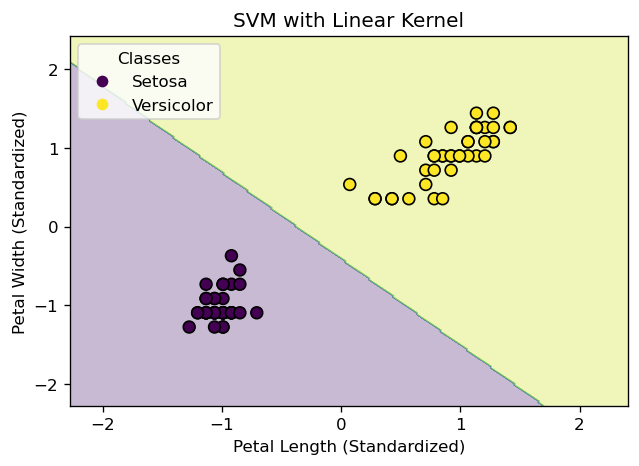

In [24]:
linear_model = SVC(kernel='linear', C=1.0)
linear_model.fit(X_train, y_train)
plot_decision_boundary(linear_model, X_train, y_train, "SVM with Linear Kernel")

> **Visual Description:** This plot illustrates a **Linear SVM** decision boundary. It shows a perfectly straight diagonal line separating two clusters of data points: purple dots (Setosa) in the bottom-left and yellow dots (Versicolor) in the top-right. The background is shaded in two distinct colors to show the decision regions, and the linear boundary clearly maximizes the margin between the two classes.

### Why Polynomial Kernel?

Polynomial kernels allow curved decision boundaries.  
We can control the complexity by adjusting the polynomial degree.

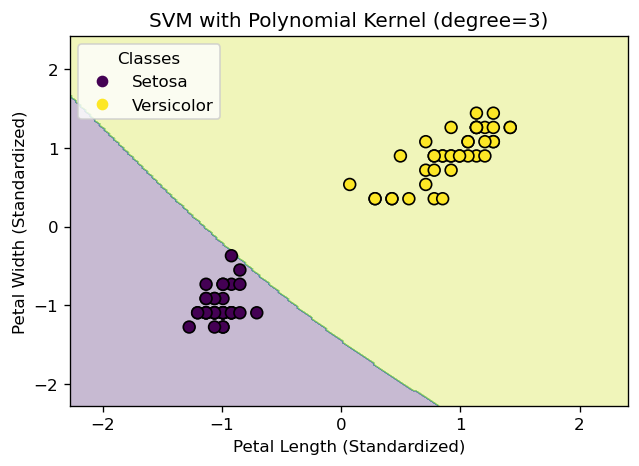

In [25]:
poly_model = SVC(kernel='poly', degree=3, C=1.0)
poly_model.fit(X_train, y_train)
plot_decision_boundary(poly_model, X_train, y_train, "SVM with Polynomial Kernel (degree=3)")

> **Visual Description:** This plot displays the **Polynomial SVM** decision boundary. The boundary is no longer a straight line but a smooth, slight curve that bends to accommodate the data distribution. The shading indicates how the polynomial transformation allows the model to separate the two classes (purple and yellow) in a non-linear fashion while maintaining a clear decision margin.

### Why RBF Kernel?

RBF (Gaussian) kernel maps data into a higher-dimensional space.  
It can handle very complex non-linear patterns.

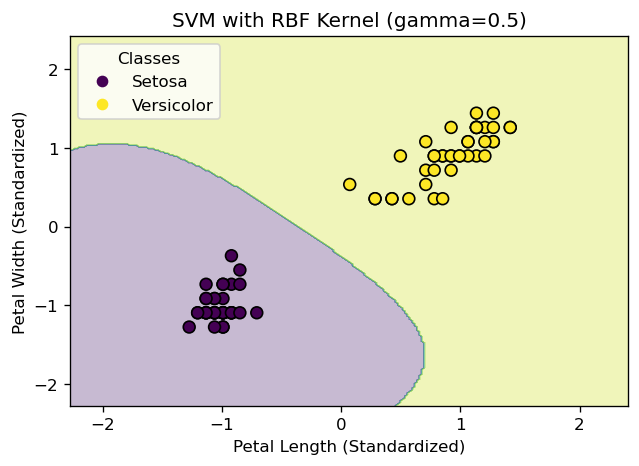

In [26]:
rbf_model = SVC(kernel='rbf', C=1.0, gamma=0.5)
rbf_model.fit(X_train, y_train)
plot_decision_boundary(rbf_model, X_train, y_train, "SVM with RBF Kernel (gamma=0.5)")

> **Visual Description:** This plot shows the **RBF (Gaussian) Kernel** decision boundary. The boundary is highly flexible and appears as a sophisticated, non-linear curve. The shaded decision regions wrap closely around the clusters of purple and yellow data points, demonstrating the RBF kernel's ability to handle complex, overlapping, or non-linear spatial relationships between classes.

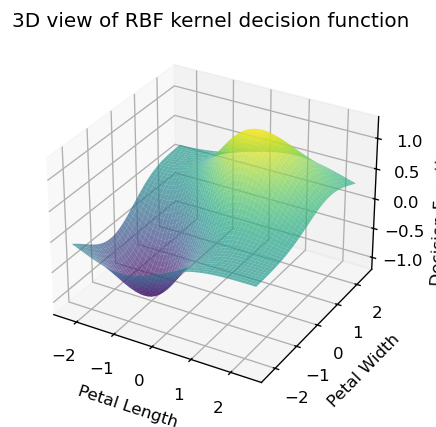

In [27]:
xx, yy = np.meshgrid(np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 50),
                     np.linspace(X_train[:,1].min()-1, X_train[:,1].max()+1, 50))
Z = rbf_model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx, yy, Z, cmap=cm.viridis, alpha=0.7)
ax.set_xlabel('Petal Length')
ax.set_ylabel('Petal Width')
ax.set_zlabel('Decision Function Value')
plt.title("3D view of RBF kernel decision function")
plt.show()

> **Visual Description:** This is a **3D surface plot** representing the decision function of the **RBF (Gaussian) Kernel**. The X and Y axes represent 'Petal Length' and 'Petal Width' respectively, while the vertical Z-axis represents the 'Decision Function Value'. The plot shows a curved, "mountain-like" surface using the color-blind friendly 'viridis' colormap. The "peaks" and "valleys" of the surface illustrate how the RBF kernel assigns high or low probabilities to different regions of the feature space, creating a flexible, non-linear boundary where the surface crosses the zero-plane.

## Results and Discussion

- **Linear Kernel:** Produces a straight line. Works well for linearly separable data.  
- **Polynomial Kernel:** Creates a curved decision boundary. Degree controls complexity.  
- **RBF Kernel:** Very flexible, can handle complex patterns. Sensitive to gamma parameter.  

Choosing the right kernel is crucial for model performance.

## My Intuition: Why Kernels Matter

When I first learned SVMs, I struggled to understand why RBF kernels work.  
Visualizing the 2D data in a 3D space helped me see that the non-linear boundary in 2D is actually **linear in higher dimensions**.  
This intuition helped me realize why choosing the right kernel is critical: the wrong kernel may underfit or overfit the data.

## Conclusion

- Kernel choice directly affects SVM decision boundaries and classification performance.  
- Linear kernel: simple and interpretable  
- Polynomial kernel: handles some non-linear data  
- RBF kernel: most flexible for complex data  
- Experiment with **degree** (polynomial) and **gamma** (RBF) for best results

**GitHub Repository:** https://github.com/sandeep1214/SVM_Kernels_Tutorial

## References

1. Boser, B., Guyon, I., & Vapnik, V. (1992). *A training algorithm for optimal margin classifiers*.  
2. Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning, 20*(3), 273–297.  
3. Scikit-learn documentation: [https://scikit-learn.org/stable/modules/svm.html](https://scikit-learn.org/stable/modules/svm.html)  
4. Analytics Vidhya blog: Understanding Kernels in SVM, 2021